In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# Definition and Justification of 3 KPI's for a Dashboard of a Hub Controller

## 1. Utilization Rate (%)
Displays the current utilization rate of the 2 charging sites. With this information, a hub controller can observe the availabilty of the current stations and can be warned if a site is fully used, which could lead to a loss of customers because no free charging spot is available.

## 2. Average Session Duration 
Displays the current average session duration at the 2 charging sites. Useful for pattern identification and a better understanding of the current hub situation.

## 3. Energy Delivered per Hour
Displays the delivered energy per hour, which can be used for resource planning and allocation.

In [2]:
data = pd.read_csv("data/cleaned_chargingdata.csv")

In [3]:
data['id'] = data['id'].astype('string')

data['connectionTime'] = pd.to_datetime(data['connectionTime'], errors='coerce', utc=True)  
data['disconnectTime'] = pd.to_datetime(data['disconnectTime'], errors='coerce', utc=True)  
data['doneChargingTime'] = pd.to_datetime(data['doneChargingTime'], errors='coerce', utc=True) 

data['sessionID'] = data['sessionID'].astype('string')
data['siteID'] = data['siteID'].astype('string')
data['spaceID'] = data['spaceID'].astype('string')
data['stationID'] = data['stationID'].astype('string')
data['timezone'] = data['timezone'].astype('string')
data['userID'] = data['userID'].astype('string')

In [4]:

data['connectionTime'] = data['connectionTime'].dt.tz_convert('America/Los_Angeles')
data['disconnectTime'] = data['disconnectTime'].dt.tz_convert('America/Los_Angeles')
data['doneChargingTime'] = data['doneChargingTime'].dt.tz_convert('America/Los_Angeles')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60907 entries, 0 to 60906
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   Unnamed: 0.1      60907 non-null  int64                              
 1   Unnamed: 0        60907 non-null  int64                              
 2   id                60907 non-null  string                             
 3   connectionTime    60907 non-null  datetime64[ns, America/Los_Angeles]
 4   disconnectTime    60907 non-null  datetime64[ns, America/Los_Angeles]
 5   doneChargingTime  60907 non-null  datetime64[ns, America/Los_Angeles]
 6   kWhDelivered      60907 non-null  float64                            
 7   sessionID         60907 non-null  string                             
 8   siteID            60907 non-null  string                             
 9   spaceID           60907 non-null  string                     

In [6]:
start_date = '2019-01-07'
end_date = '2019-01-13'

## 1. Utilization Rate

In [22]:
# data['hour'] = data['connectionTime'].dt.hour
# data['date_hour'] = data['connectionTime'].dt.floor('H')
# total_chargers = data['stationID'].nunique()

C:\Users\User\AppData\Local\Temp\ipykernel_111932\3985811069.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data['date_hour'] = data['connectionTime'].dt.floor('H')


In [7]:
all_hours = pd.date_range(start=start_date, end=end_date, freq='h')

In [8]:
start_of_hour = hour
end_of_hour = hour + pd.Timedelta(hours=1)


NameError: name 'hour' is not defined

In [ ]:
active_chargers = data[(data['connectionTime'] <= end_of_hour) & (data['disconnectTime'] >= start_of_hour)]

In [23]:
# chargers_in_use = data.groupby('hour').size().reset_index(name='chargers_in_use')
# chargers_in_use['utilization_rate'] = (chargers_in_use['chargers_in_use'] / total_chargers) * 100

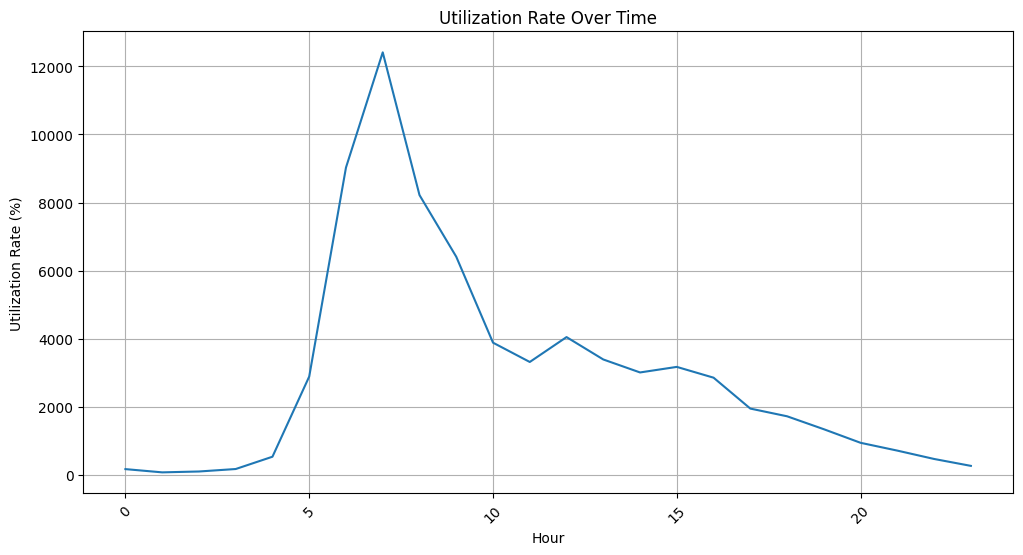

In [24]:
# plt.figure(figsize=(12, 6))
# sns.lineplot(data=chargers_in_use, x='hour', y='utilization_rate')
# plt.title('Utilization Rate Over Time')
# plt.xlabel('Hour')
# plt.ylabel('Utilization Rate (%)')
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.show()

## 2. Average Session Duration

In [25]:
data['session_duration'] = (data['disconnectTime'] - data['connectionTime']).dt.total_seconds() / 60.0

average_duration = data['session_duration'].mean()

print(f"Average Duration of Charging Sessions: {average_duration:.2f} minutes")

Average Duration of Charging Sessions: 380.99 minutes


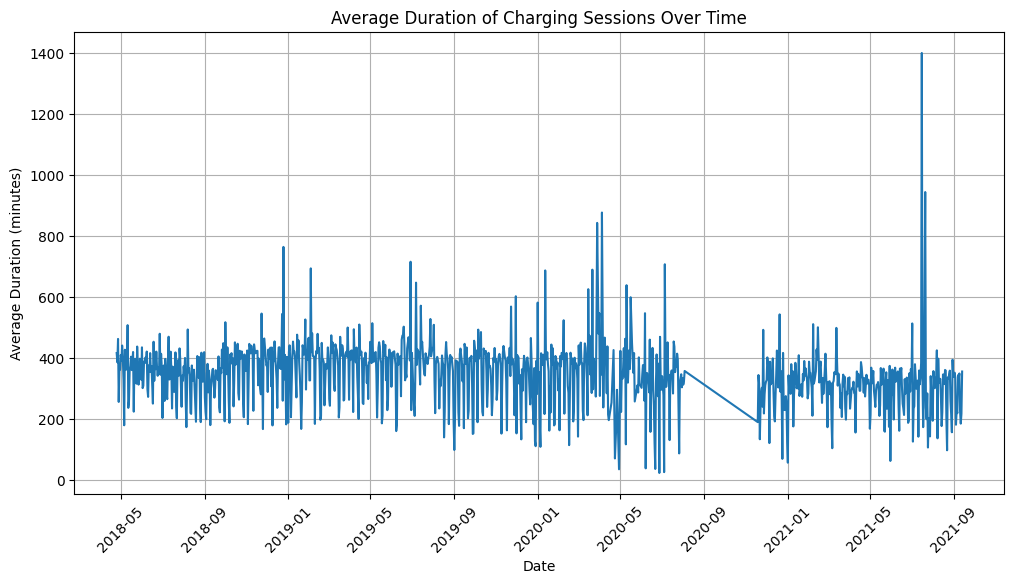

In [26]:
# Group by day and calculate the average duration for each day
data['date'] = data['connectionTime'].dt.date
average_duration_per_day = data.groupby('date')['session_duration'].mean().reset_index()

# Line plot of the average duration over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_duration_per_day, x='date', y='session_duration')
plt.title('Average Duration of Charging Sessions Over Time')
plt.xlabel('Date')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Energy Delivered per Hour (WIP) -- current approach can be found in dev_Xiaofeng -> 2 descriptive analytics.ipynb

In [ ]:
# TODO's:
# merge KPI notebooks and finish hourly calculation of KPI's
# visualize calculated KPI's and interpret observable trends
# expand justifications
# optional: find references for selected KPI's